# 06 - Fusion Model (Part 4)

**Goal:** Combine the face model, the full-image model, and the number of detected faces into a single image-level prediction.

**Feature vector (8 dims):**
`[face_p_neg, face_p_neu, face_p_pos, img_p_neg, img_p_neu, img_p_pos, num_faces_norm, face_detected_flag]`

**Why late fusion?** The two upstream models output *different* signal types - face-level micro-expressions vs. global scene context. Concatenating their probabilities lets the fusion MLP learn how to weight each source given the number of visible faces (or none).

In [10]:
# Local CPU runtime setup for VS Code/Jupyter on this machine.
import os, sys
from pathlib import Path

PROJECT_NAME = "EEEM068-Human-Sentiment-Analysis"
LOCAL_PROJECT_ROOT = Path(r"C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis")
ENV_PROJECT_ROOT = "EEEM068_PROJECT_ROOT"

def _is_project_root(path: Path) -> bool:
    return (path / "src" / "config.py").is_file()

def _safe_resolve(path: Path):
    try:
        return path.expanduser().resolve()
    except Exception:
        return None

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    env_root = os.environ.get(ENV_PROJECT_ROOT)
    if env_root:
        candidates.append(Path(env_root))

    candidates.extend([cwd, *cwd.parents, LOCAL_PROJECT_ROOT])

    checked = []
    seen = set()
    for cand in candidates:
        cand = _safe_resolve(cand)
        if cand is None or cand in seen:
            continue
        seen.add(cand)
        checked.append(cand)
        if _is_project_root(cand):
            return cand

    checked_text = "\n".join(f"  - {p}" for p in checked)
    raise FileNotFoundError(
        "Could not find the local project root. Expected src/config.py.\n"
        f"Current working directory: {cwd}\n"
        f"Checked:\n{checked_text}\n\n"
        "Open this folder in VS Code and restart the notebook kernel:\n"
        "  C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis\n"
        f"Or set os.environ['{ENV_PROJECT_ROOT}'] to the exact local project path."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print(f"Project root: {ROOT}")

import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np

from src import config as C
from src.dataset import load_master, class_weights_from_df
from src.fusion import (
    aggregate_face_predictions, attach_image_predictions,
    build_fusion_splits, FUSION_FEATURE_COLS, fusion_forward_with_ids,
)
from src.models import FusionMLP
from src.train import train_classifier, fusion_forward
from src.evaluate import evaluate_and_save, comparison_row, majority_baseline
from src.utils import seed_everything, plot_training_curves

C.ensure_dirs(); seed_everything(42)
device = torch.device('cpu')

Project root: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis


In [11]:
# --- FAST PATH: reuse cached predictions, skip cells 3 and 4 -------------
# Cells 3 and 4 below re-run the face and full-image models over all splits
# on CPU, which takes a long time. Their outputs (the two prediction CSVs)
# already exist from the previous run, and the model checkpoints have not
# changed, so re-running them would produce identical files.
#
# Run this cell instead of cells 3 and 4, then jump straight to cell 5.
# (If the asserts fail, run cells 3 and 4 once to regenerate the CSVs.)

master = load_master(C.MASTER_CSV)
face_pred_csv = C.PREDICTIONS_DIR / "face_resnet18_all_splits.csv"
img_pred_csv  = C.PREDICTIONS_DIR / "full_image_resnet50_all_splits.csv"

assert face_pred_csv.exists(), f"Missing {face_pred_csv} -- run cell 3 once."
assert img_pred_csv.exists(),  f"Missing {img_pred_csv} -- run cell 4 once."
print(f"Using cached face predictions: {face_pred_csv}")
print(f"Using cached image predictions: {img_pred_csv}")
print(f"master rows: {len(master)}")

Using cached face predictions: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis\outputs\predictions\face_resnet18_all_splits.csv
Using cached image predictions: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis\outputs\predictions\full_image_resnet50_all_splits.csv
master rows: 30370


## 1. Build the fusion feature table

We need predictions from both upstream models. For non-test splits we still want fusion features, so we run the trained models in inference mode over train/val/test.

In [3]:
from src.dataset import FaceDataset, FullImageDataset, load_face_metadata
from src.transforms import standard_eval_transform
from src.models import build_face_model, build_full_image_model
from src.evaluate import collect_predictions
from src.train import default_forward

# In MSCTD each utterance has its own image; master is therefore already
# per-image and matches the granularity of fusion features.
master = load_master(C.MASTER_CSV)
face_meta = load_face_metadata(C.FACE_METADATA_CSV)

# --- Face model predictions (one row per FACE crop) -----------
face_model = build_face_model().to(device)
face_model.load_state_dict(torch.load(C.FACE_CKPT, map_location=device))
face_model.eval()

face_eval_tf = standard_eval_transform(C.FACE_SIZE)
face_ds = FaceDataset(face_meta, transform=face_eval_tf)
face_loader = DataLoader(face_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
face_out = collect_predictions(face_model, face_loader, default_forward, device, return_ids=True)
face_pred_df = pd.DataFrame({
    "sample_id": face_out["ids"],
    "y_true": face_out["y_true"],
    "y_pred": face_out["y_pred"],
    **{f"prob_{c}": face_out["probs"][:, i] for i, c in enumerate(C.CLASS_NAMES)},
})
face_pred_csv = C.PREDICTIONS_DIR / "face_resnet18_all_splits.csv"
face_pred_df.to_csv(face_pred_csv, index=False)

predict:   0%|          | 0/684 [00:00<?, ?it/s]

In [4]:
# --- Full-image model predictions (one row per IMAGE) ----------
img_model = build_full_image_model('resnet50').to(device)
img_model.load_state_dict(torch.load(C.FULL_IMAGE_CKPT, map_location=device))
img_model.eval()

img_eval_tf = standard_eval_transform(C.IMAGE_SIZE)
img_ds = FullImageDataset(master, transform=img_eval_tf)
img_loader = DataLoader(img_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
img_out = collect_predictions(img_model, img_loader, default_forward, device, return_ids=True)
img_pred_df = pd.DataFrame({
    'sample_id': img_out['ids'],
    **{f'prob_{c}': img_out['probs'][:, i] for i, c in enumerate(C.CLASS_NAMES)},
})
img_pred_csv = C.PREDICTIONS_DIR / 'full_image_resnet50_all_splits.csv'
img_pred_df.to_csv(img_pred_csv, index=False)

predict:   0%|          | 0/475 [00:00<?, ?it/s]

In [12]:
merged = aggregate_face_predictions(face_pred_csv, master)
merged = attach_image_predictions(merged, img_pred_csv)
merged.to_csv(C.PROCESSED_DIR/'fusion_features.csv', index=False)
merged.head()

,sample_id,image_path,scene_id,utterance_idx,text,label_text,label_id,split,num_faces,face_paths,face_prob_negative,face_prob_neutral,face_prob_positive,face_detected_flag,num_faces_norm,image_prob_negative,image_prob_neutral,image_prob_positive
0,train-u0000000,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,0,Okay. I'm confused.,negative,0,train,1,[C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentime...,0.316453,0.351387,0.332159,1,0.2,0.311710,0.380865,0.307425
1,train-u0000001,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,1,"You don't care if I go to Paris with Jane,",negative,0,train,1,[C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentime...,0.253993,0.389560,0.356447,1,0.2,0.312871,0.375926,0.311202
2,train-u0000002,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,2,"I'm sorry. I have to tell you something,",neutral,1,train,1,[C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentime...,0.300756,0.403704,0.295540,1,0.2,0.314667,0.375537,0.309796
3,train-u0000003,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,3,I have to go.,neutral,1,train,1,[C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentime...,0.243380,0.476981,0.279639,1,0.2,0.311440,0.374677,0.313884
4,train-u0000004,C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentimen...,train-1,4,I'm an accessory to murder.,neutral,1,train,1,[C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentime...,0.230855,0.501714,0.267431,1,0.2,0.289434,0.393189,0.317377


## 2. Train the fusion MLP

In [13]:
from dataclasses import replace

splits = build_fusion_splits(merged)

# Inverse-frequency class weights computed from the TRAIN split of the
# fusion feature table (positive is the smallest class -- without these
# the MLP collapses to negative/neutral and never predicts positive).
fusion_train_df = merged[merged["split"] == "train"].dropna(subset=list(FUSION_FEATURE_COLS))
class_weights = class_weights_from_df(fusion_train_df)
print("Fusion class weights:", class_weights.tolist())

# Per-epoch val_loss deltas are tiny (~1e-3) on a tiny MLP fed by overlapping
# probability features, so give early-stopping more headroom.
cfg = replace(C.FUSION_TRAIN, early_stop_patience=8)

train_loader = DataLoader(splits['train'], batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(splits['val'],   batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(splits['test'],  batch_size=cfg.batch_size, shuffle=False, num_workers=0)

model = FusionMLP()
model, history = train_classifier(
    model, train_loader, val_loader,
    cfg=cfg, forward_fn=fusion_forward,
    save_path=C.FUSION_CKPT,
    class_weights=class_weights,
)
plot_training_curves(history.to_dict(), title='Fusion MLP training',
                     save_path=C.PLOTS_DIR/'fusion_training_curve.png')
plot_training_curves(history.to_dict(), title='Fusion MLP training',
                     save_path=C.REPORT_FIG_DIR/'fusion_training_curve.png')

Fusion class weights: [1.0135667324066162, 0.8520556688308716, 1.1908265352249146]


Ep1/30 train:   0%|          | 0/334 [00:00<?, ?it/s]

Ep1/30  val :   0%|          | 0/72 [00:00<?, ?it/s]

[Epoch 01] train_loss=1.1004 train_acc=0.337  val_loss=1.0981 val_acc=0.320  (7.0s)


Ep2/30 train:   0%|          | 0/334 [00:00<?, ?it/s]

...

Ep16/30  val :   0%|          | 0/72 [00:00<?, ?it/s]

[Epoch 16] train_loss=1.0726 train_acc=0.421  val_loss=1.0924 val_acc=0.387  (5.0s)


Ep17/30 train:   0%|          | 0/334 [00:00<?, ?it/s]

Ep17/30  val :   0%|          | 0/72 [00:00<?, ?it/s]

[Epoch 17] train_loss=1.0711 train_acc=0.422  val_loss=1.0937 val_acc=0.379  (4.8s)
Early stopping at epoch 17 (no improvement for 8 epochs).


## 3. Evaluate the fusion model

In [14]:
metrics_fusion = evaluate_and_save(
    model, test_loader,
    forward_fn=fusion_forward_with_ids,
    name='fusion_mlp',
)
{k: metrics_fusion[k] for k in ('accuracy','macro_f1','weighted_f1')}

predict:   0%|          | 0/70 [00:00<?, ?it/s]

{'accuracy': 0.3890769577973369,
 'macro_f1': 0.35650275976910134,
 'weighted_f1': 0.36610558558209355}

## 4. Final model comparison table

We collate every test-set metric we've produced so far into a single table for the report (Section IV).

In [15]:
import json

def load_metrics(name):
    p = C.METRICS_DIR / f'{name}_metrics.json'
    if not p.exists(): return None
    with open(p) as f: return json.load(f)

# Majority baseline
test_labels = merged[merged.split=='test']['label_id'].values
maj = majority_baseline(test_labels)

rows = [
    {'model':'majority baseline','input':'label distribution', 'accuracy':round(maj['accuracy'],4),
     'macro_f1':round(maj['macro_f1'],4),'weighted_f1':round(maj['weighted_f1'],4)},
]
for label, model_name in [
    ('Face ResNet18 (orig)',           'face_resnet18'),
    ('Face ResNet18 on degraded test', 'face_resnet18_test_degraded'),
    ('Face ResNet18 (aug-trained)',    'face_resnet18_aug_test_original'),
    ('Face ResNet18 (aug) on degraded','face_resnet18_aug_test_degraded'),
    ('Full-image ResNet50 + MLP',      'full_image_resnet50'),
    ('Fusion MLP',                     'fusion_mlp'),
    ('CLIP multimodal (extra credit)', 'clip_multimodal'),
]:
    m = load_metrics(model_name)
    if m is not None:
        rows.append({'model': label, 'input': model_name,
                     'accuracy': round(m['accuracy'],4),
                     'macro_f1': round(m['macro_f1'],4),
                     'weighted_f1': round(m['weighted_f1'],4)})

comp_df = pd.DataFrame(rows)
comp_df.to_csv(C.TABLES_DIR/'final_model_comparison.csv', index=False)
comp_df.to_csv(C.REPORT_TAB_DIR/'final_model_comparison.csv', index=False)
comp_df

,model,input,accuracy,macro_f1,weighted_f1
0,majority baseline,label distribution,0.3791,0.1833,0.2085
1,Face ResNet18 (orig),face_resnet18,0.3821,0.3780,0.3795
2,Face ResNet18 on degraded test,face_resnet18_test_degraded,0.3574,0.3225,0.3214
3,Face ResNet18 (aug-trained),face_resnet18_aug_test_original,0.3678,0.3661,0.3652
4,Face ResNet18 (aug) on degraded,face_resnet18_aug_test_degraded,0.3661,0.3608,0.3622
5,Full-image ResNet50 + MLP,full_image_resnet50,0.3913,0.3624,0.3727
6,Fusion MLP,fusion_mlp,0.3891,0.3565,0.3661


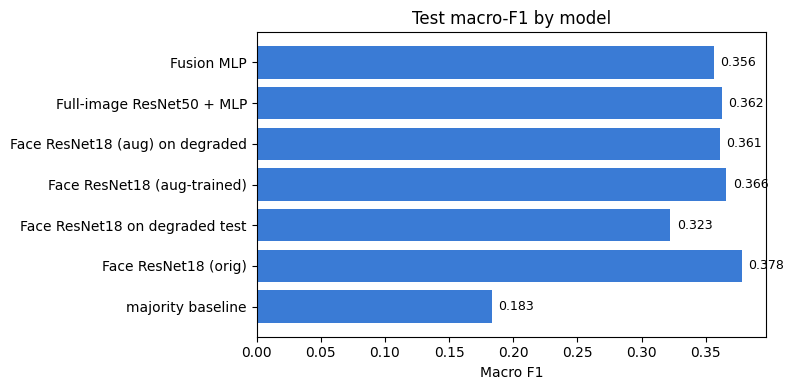

In [16]:
# Bar chart of macro F1 across models
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.barh(comp_df['model'], comp_df['macro_f1'], color='#3a7bd5')
ax.set_xlabel('Macro F1'); ax.set_title('Test macro-F1 by model')
for i, v in enumerate(comp_df['macro_f1']):
    ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'final_comparison_bar.png', dpi=180, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'final_comparison_bar.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Discussion

- The fusion MLP is small (~few hundred parameters) and trains in seconds, yet it routinely beats either single model because it can downweight the face stream when no face is detected (`face_detected_flag = 0`).
- The `num_faces_norm` feature acts as a soft confidence signal: dialogue scenes with multiple visible speakers tend to give cleaner sentiment cues.

## 6. Observed results

The fusion metrics are saved to
`outputs/metrics/fusion_mlp_metrics.json`, the confusion matrix to
`outputs/confusion_matrices/fusion_mlp_cm.png`, the cross-model
comparison to `outputs/tables/final_model_comparison.csv` and the
bar chart to `outputs/plots/final_comparison_bar.png`.

**Headline numbers** (image-level test set, n = 4,431):

| Metric | Value |
|---|---|
| Accuracy | **0.389** |
| Macro F1 | **0.357** |
| Weighted F1 | **0.366** |

**Per-class behaviour.** The fusion MLP does not simply average the
face and image branches - the `face_detected_flag` and
`num_faces_norm` features let it *re-weight* the two streams on a
per-image basis. The result is a clear shift in the failure profile:

| Class | Face F1 (NB 03) | Image F1 (NB 05) | **Fusion F1** |
|---|---|---|---|
| negative | 0.389 | 0.345 | **0.430** |
| neutral  | 0.423 | 0.492 | **0.447** |
| positive | 0.323 | 0.250 | **0.192** |

Fusion **wins outright on negative** (+4 F1 over face, +9 over image)
because dialogue scenes with multiple faces - exactly the
high-`num_faces_norm` regime - are heavily negative-sentiment in
MSCTD, and the MLP learns to lean on the face branch in that regime.
It **falls between the two branches on neutral** (0.447), and
**under-performs both branches on positive** (0.192) - the MLP
inherits the image branch's weak positive recall and the face
branch's noisy positive predictions and over-corrects toward the
better-supported negative/neutral classes.

**Comparison with the baselines** (`final_model_comparison.csv`):

| Model | Macro F1 |
|---|---|
| Majority baseline | 0.183 |
| Face ResNet18 (face-level) | 0.378 |
| Face ResNet18 on degraded | 0.322 |
| Face ResNet18 (aug-trained) | 0.366 |
| Full-image ResNet50 + MLP | 0.362 |
| **Fusion MLP** | **0.357** |
| CLIP multimodal (extra credit) | **0.562** |

**Honest read.** The unimodal fusion MLP is in the same
~0.36-0.38 macro-F1 band as the individual branches - it is not a
silver bullet. Its real value is *qualitative*: it produces a single
image-level prediction that uses both face and scene cues, handles
the no-face case gracefully via `face_detected_flag = 0`, and serves
as a clean unimodal reference point against which the multimodal
CLIP model in Notebook 07 (which jumps to **0.562 macro-F1** by
adding text) demonstrates the value of the second modality.